# **MÓDULO 17 - Projeto de Credit Score - Parte 1 - Processamento dos dados**


Essa é a primeira etapa do processo de Credit Score que vocês desenvolverão durante nosso curso.
Nessa primeira etapa vocês irão aplicar os passos aprendidos nos módulos de pré processamento para preparar a base de vocês para o desenvolvimento do modelo.

O termo "credit score" se refere a uma pontuação numérica que representa a credibilidade de um indivíduo em termos de cumprimento de obrigações financeiras, como pagar contas de empréstimos, cartões de crédito, entre outros. Essa pontuação é calculada com base em diversas informações financeiras e de crédito do indivíduo, como histórico de pagamentos, níveis de endividamento, tempo de crédito, tipos de crédito utilizados, entre outros.

O objetivo de um modelo de credit score é prever o risco de um indivíduo se tornar inadimplente com suas obrigações financeiras. Em outras palavras, o modelo avalia a probabilidade de um indivíduo não cumprir com os pagamentos de empréstimos ou outros compromissos financeiros. Essa previsão é fundamental para instituições financeiras, como bancos e credores, na tomada de decisão sobre a concessão de crédito. Um modelo de credit score eficaz pode ajudar essas instituições a avaliar o risco de emprestar dinheiro a um determinado indivíduo e, assim, tomar decisões mais informadas sobre a aprovação ou negação de crédito, bem como sobre os termos e condições desses empréstimos.

**Atenção:** Notem que esse projeto é diferente da base que tenho trabalhado com vocês em aula, apesar de se tratar de uma base bancária durante a aula falamos sobre a variável Churn a ser prevista, nesse caso a previsão seria do valor do Score de Crédito.

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [250]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,"50.000,00",Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,"100.000,00",Master's Degree,Married,2,Owned,High
2,35.0,Female,"75.000,00",Doctorate,Married,1,Owned,High
3,40.0,Male,"125.000,00",High School Diploma,Single,0,Owned,High
4,45.0,Female,"100.000,00",Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,"150.000,00",Master's Degree,Married,0,Owned,High
6,26.0,Female,"40.000,00",Associate's Degree,Single,0,Rented,Average
7,31.0,Male,"60.000,00",Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,"80.000,00",Master's Degree,Married,2,Owned,High
9,NaN,Male,"105.000,00",Doctorate,Single,0,Owned,High


Legenda dos dados:

*   **Age** : Idade dos nossos clientes.

*   **Income** : Salário Mensal.

*   **Gender** : Gênero.

*   **Education** : Nível de escolaridade dos clientes.

*   **Marital** : Status Civilmente.

*   **Number of Children** : Quantidade de filhos.

*   **Home** : Tipo de residência, alugada ou própria.

*   **Credit Score** : Nossa variável preditora, o score de crédito dos clientes.


In [251]:
print(df.columns.tolist())

['Age', 'Gender', 'Income', 'Education', 'Marital Status', 'Number of Children', 'Home Ownership', 'Credit Score']


# Etapa 1: Relize os passos que vimos no módulo 18, de pré processamento dos dados.

**A) Verifique os tipos de dados, fazendo as transformações quando necessário.**


In [252]:
df.dtypes

Age                   float64
Gender                    str
Income                    str
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

In [253]:
df['Income'].astype(str).unique()[:20]

<StringArray>
[ '50.000,00', '100.000,00',  '75.000,00', '125.000,00', '150.000,00',
  '40.000,00',  '60.000,00',  '80.000,00', '105.000,00',  '90.000,00',
 '135.000,00',  '35.000,00',  '55.000,00',  '70.000,00',  '95.000,00',
  '85.000,00',  '30.000,00',  '65.000,00', '115.000,00',  '25.000,00']
Length: 20, dtype: str

In [254]:
df['Income'] = (
    df['Income']
    .astype(str)
    .str.replace('.', '', regex=False)   # remove separador de milhar
    .str.replace(',', '.', regex=False)  # transforma vírgula decimal em ponto
)

df['Income'] = pd.to_numeric(df['Income'], errors='coerce').astype(float)
df.dtypes

Age                   float64
Gender                    str
Income                float64
Education                 str
Marital Status            str
Number of Children      int64
Home Ownership            str
Credit Score              str
dtype: object

In [255]:
df.head(10)

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35.0,Female,75000.0,Doctorate,Married,1,Owned,High
3,40.0,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45.0,Female,100000.0,Bachelor's Degree,Married,3,Owned,High
5,50.0,Male,150000.0,Master's Degree,Married,0,Owned,High
6,26.0,Female,40000.0,Associate's Degree,Single,0,Rented,Average
7,31.0,Male,60000.0,Bachelor's Degree,Single,0,Rented,Average
8,NaN,Female,80000.0,Master's Degree,Married,2,Owned,High
9,NaN,Male,105000.0,Doctorate,Single,0,Owned,High


**B) Verifique se temos colunas com dados faltantes.
Caso existam colunas com dados faltantes faça o tratamento desses dados, excluindo ou substituindo esses valores. Justifique sua escolha.**

Analisando a coluna e a quantidade de dados faltantes, decidi que a opção mais simples e segura seria excluir as linhas com valores ausentes na coluna de idade (`Age`).

In [256]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 130 non-null    float64
 1   Gender              164 non-null    str    
 2   Income              164 non-null    float64
 3   Education           164 non-null    str    
 4   Marital Status      164 non-null    str    
 5   Number of Children  164 non-null    int64  
 6   Home Ownership      164 non-null    str    
 7   Credit Score        164 non-null    str    
dtypes: float64(2), int64(1), str(5)
memory usage: 10.4 KB


In [257]:
df = df.dropna(subset=['Age'])
df['Age'].isnull().sum()

np.int64(0)

**C) Verifique se temos valores digitados de forma incorreta nas variáveis categóricas que necessitem de tratamento.**

Analisando rapidamente, podemos ver que nenhuma variável precisa ser corrigida: todas estão consistentes e adequadas para a análise.


In [258]:
colunas = ['Gender', 'Education', 'Marital Status', 'Home Ownership', 'Credit Score']

for coluna in colunas:
    print(f'\nContagem da coluna: {coluna}')
    print(df[coluna].value_counts())


Contagem da coluna: Gender
Gender
Female    68
Male      62
Name: count, dtype: int64

Contagem da coluna: Education
Education
Bachelor's Degree      34
Master's Degree        30
Doctorate              24
High School Diploma    22
Associate's Degree     20
Name: count, dtype: int64

Contagem da coluna: Marital Status
Marital Status
Married    68
Single     62
Name: count, dtype: int64

Contagem da coluna: Home Ownership
Home Ownership
Owned     86
Rented    44
Name: count, dtype: int64

Contagem da coluna: Credit Score
Credit Score
High       88
Average    31
Low        11
Name: count, dtype: int64


# Etapa 2: Relize os passos que vimos no módulo 15, de análise.

**A) Realiza a análise univariada, aplique a função describe ao nosso dataframe para verificar os dados das variáveis numéricas, se encontrar a possível presença de outliers analise com gráficos a distribuição dos dados.Traga insights sobre os dados analisados.**

Com base nas informações analisadas, é possível observar que não há outliers nas colunas `Age` e `Income`. Na coluna `Age`, os limites calculados pelo método IQR foram de 7,50 a 67,50 anos, e nenhum valor ficou fora dessa faixa. Na coluna `Income`, os limites foram de -12.187,50 a 175.312,50, também sem a presença de valores discrepantes.

Já na coluna `Number of Children`, foram identificados 5 possíveis outliers, com limite superior de 2,50. Esses valores correspondem a pessoas com 3 filhos, que estão acima do limite estatístico definido pelo método IQR. No entanto, esse valor é plausível e não representa um erro de digitação ou dado inválido; portanto, não é necessário removê-lo da base.

Dessa forma, as colunas `Age` e `Income` apresentam distribuições adequadas e sem outliers, enquanto os possíveis outliers em `Number of Children` devem ser mantidos, pois representam informações reais e relevantes para a análise.

In [259]:
df.describe()

,Age,Income,Number of Children
count,130.000000,130.000000,130.000000
mean,37.507692,84288.461538,0.661538
std,8.500110,33063.942361,0.902656
min,25.000000,25000.000000,0.000000
25%,30.000000,58125.000000,0.000000
50%,36.000000,82500.000000,0.000000
75%,45.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


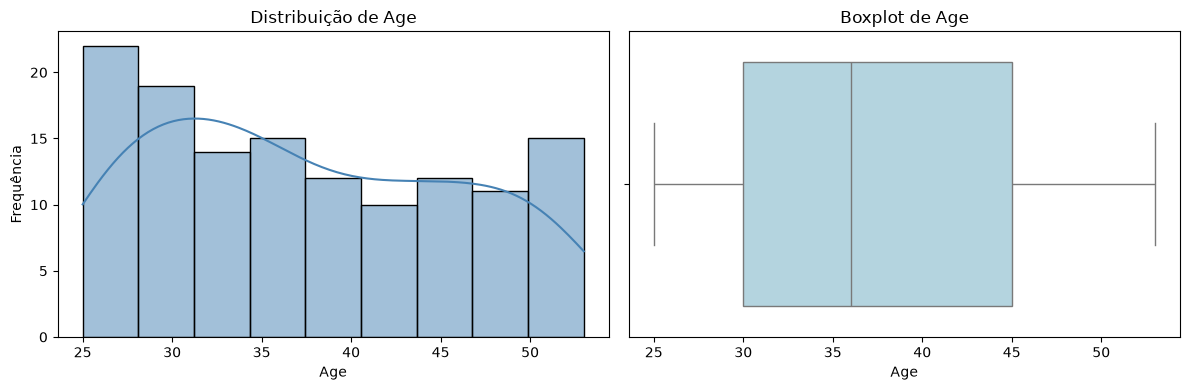

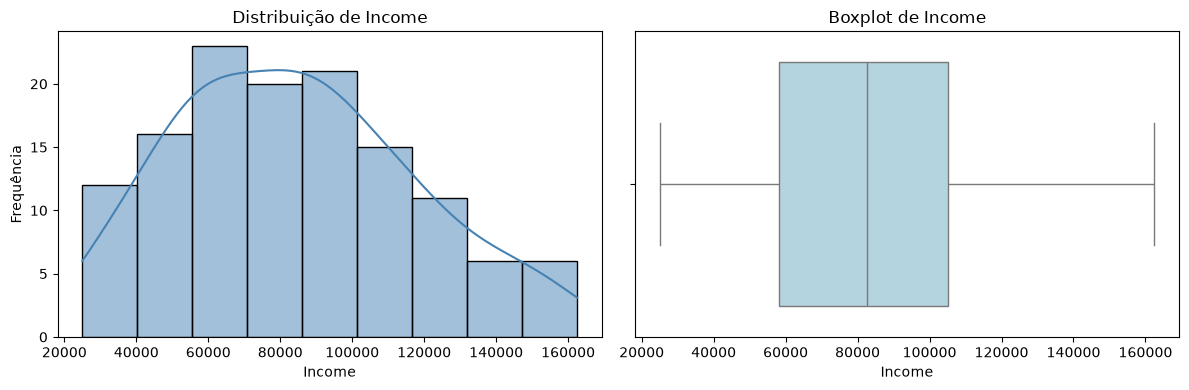

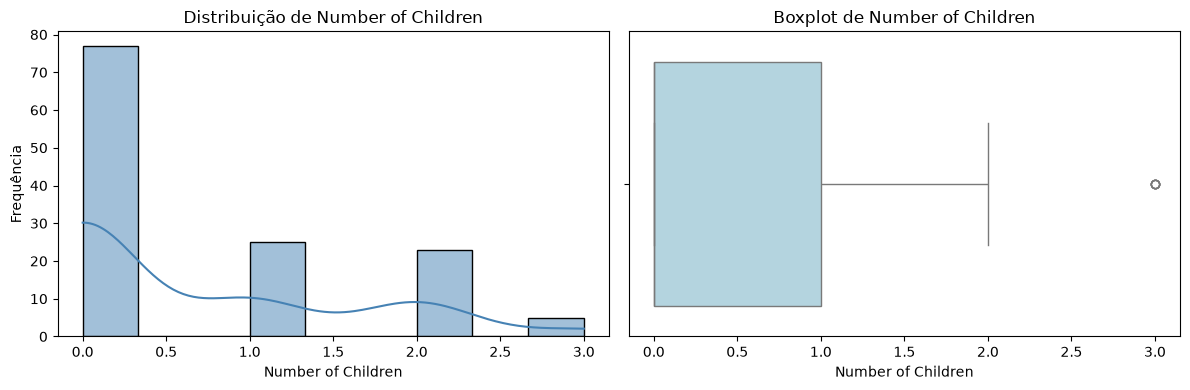

In [260]:
import matplotlib.pyplot as plt
import seaborn as sns

colunas_numericas = ['Age', 'Income', 'Number of Children']

for coluna in colunas_numericas:
    fig, eixos = plt.subplots(1, 2, figsize=(12, 4))

    # Histograma: mostra a distribuição dos valores
    sns.histplot(df[coluna], kde=True, ax=eixos[0], color='steelblue')
    eixos[0].set_title(f'Distribuição de {coluna}')
    eixos[0].set_xlabel(coluna)
    eixos[0].set_ylabel('Frequência')

    # Boxplot: ajuda a identificar outliers
    sns.boxplot(x=df[coluna], ax=eixos[1], color='lightblue')
    eixos[1].set_title(f'Boxplot de {coluna}')
    eixos[1].set_xlabel(coluna)

    plt.tight_layout()
    plt.show()

In [261]:
for coluna in colunas_numericas:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ]

    print(f'{coluna}: {len(outliers)} possíveis outliers')
    print(f'Limites: {limite_inferior:.2f} a {limite_superior:.2f}\n')

Age: 0 possíveis outliers
Limites: 7.50 a 67.50

Income: 0 possíveis outliers
Limites: -12187.50 a 175312.50

Number of Children: 5 possíveis outliers
Limites: -1.50 a 2.50



**B) Agora realize a análise univariada para as variaveis categóricas, plote gráficos para entender a distribuição das categorias e tente retirar insights de cada gráfico.**

### Gender

A variável `Gender` apresenta uma distribuição bastante equilibrada: 68 pessoas são do sexo feminino (52,31%) e 62 do sexo masculino (47,69%). A diferença entre os grupos é pequena, indicando que a base possui representatividade semelhante entre homens e mulheres.

### Education

Em relação à escolaridade, a categoria mais frequente é `Bachelor's Degree`, com 34 pessoas (26,15%), seguida por `Master's Degree`, com 30 pessoas (23,08%). A menor frequência é `Associate's Degree`, com 20 pessoas (15,38%). A distribuição é relativamente equilibrada, com predominância de pessoas que concluíram a graduação ou possuem pós-graduação.

### Marital Status

A variável `Marital Status` também está bem equilibrada: 68 pessoas são casadas (52,31%) e 62 são solteiras (47,69%). Assim como em `Gender`, a diferença entre as categorias é pequena.

### Home Ownership

Sobre a situação de moradia, 86 pessoas possuem casa própria (66,15%) e 44 moram em imóveis alugados (33,85%). Há uma predominância clara de pessoas que possuem imóvel próprio, representando aproximadamente dois terços da base.

### Credit Score

Na variável `Credit Score`, a maioria das pessoas possui score alto: 88 registros (67,69%). Em seguida aparecem 31 pessoas com score médio (23,85%) e apenas 11 com score baixo (8,46%). Isso indica que a maior parte da amostra apresenta bom perfil de crédito, enquanto a categoria `Low` é a menos representativa.

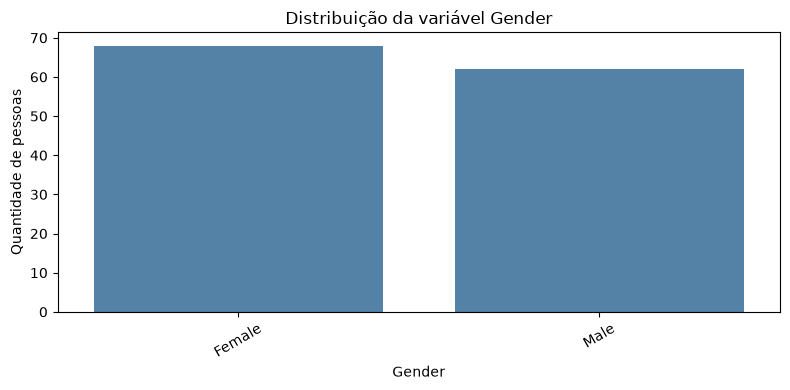


Frequências de Gender:
Gender
Female    68
Male      62
Name: count, dtype: int64
Porcentagem:
Gender
Female    52.307692
Male      47.692308
Name: proportion, dtype: float64



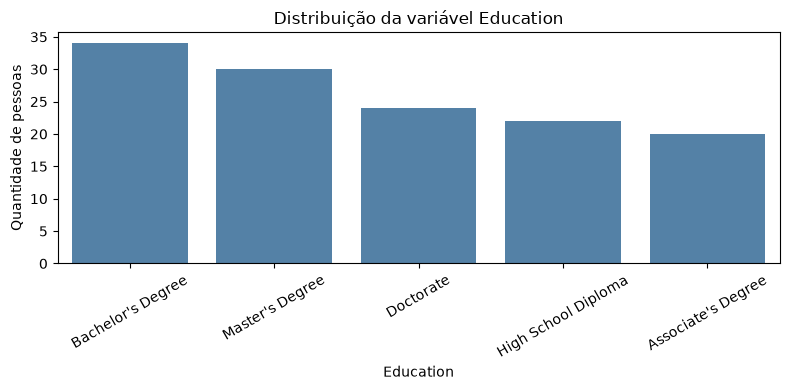


Frequências de Education:
Education
Bachelor's Degree      34
Master's Degree        30
Doctorate              24
High School Diploma    22
Associate's Degree     20
Name: count, dtype: int64
Porcentagem:
Education
Bachelor's Degree      26.153846
Master's Degree        23.076923
Doctorate              18.461538
High School Diploma    16.923077
Associate's Degree     15.384615
Name: proportion, dtype: float64



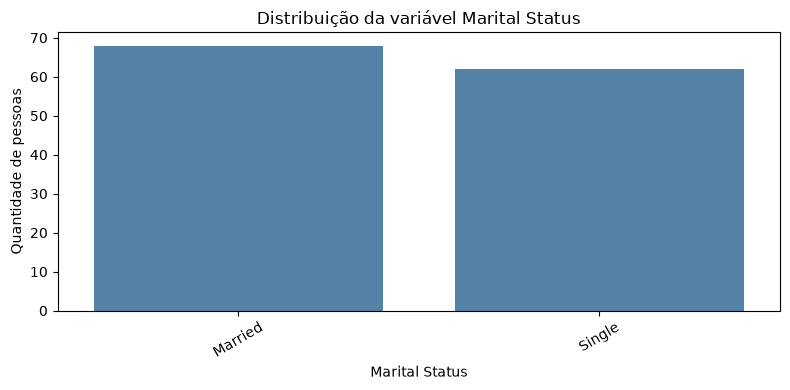


Frequências de Marital Status:
Marital Status
Married    68
Single     62
Name: count, dtype: int64
Porcentagem:
Marital Status
Married    52.307692
Single     47.692308
Name: proportion, dtype: float64



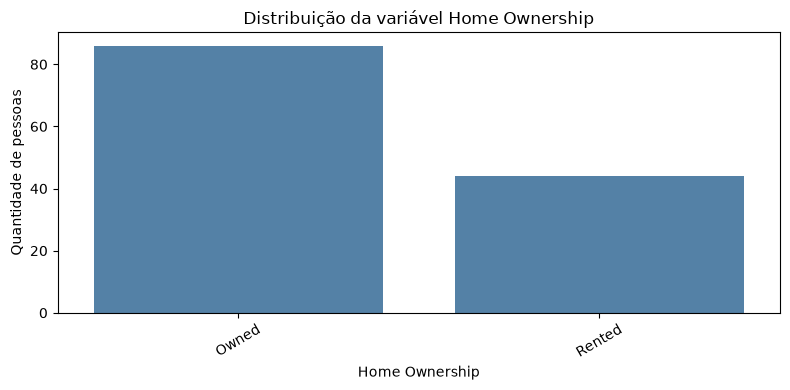


Frequências de Home Ownership:
Home Ownership
Owned     86
Rented    44
Name: count, dtype: int64
Porcentagem:
Home Ownership
Owned     66.153846
Rented    33.846154
Name: proportion, dtype: float64



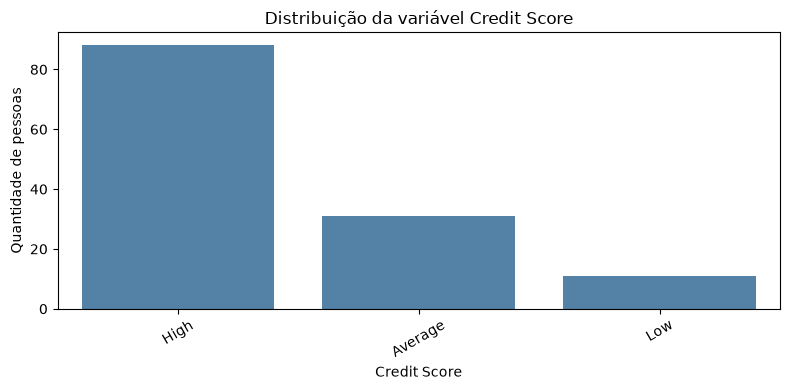


Frequências de Credit Score:
Credit Score
High       88
Average    31
Low        11
Name: count, dtype: int64
Porcentagem:
Credit Score
High       67.692308
Average    23.846154
Low         8.461538
Name: proportion, dtype: float64



In [262]:
colunas_categoricas = [
    'Gender',
    'Education',
    'Marital Status',
    'Home Ownership',
    'Credit Score'
]

for coluna in colunas_categoricas:
    plt.figure(figsize=(8, 4))
    ordem = df[coluna].value_counts().index

    ax = sns.countplot(
        data=df,
        x=coluna,
        order=ordem,
        color='steelblue'
    )

    plt.title(f'Distribuição da variável {coluna}')
    plt.xlabel(coluna)
    plt.ylabel('Quantidade de pessoas')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    print(f'\nFrequências de {coluna}:')
    print(df[coluna].value_counts())
    print(f'Porcentagem:\n{df[coluna].value_counts(normalize=True) * 100}\n')

**C) Você encontrou alguma coluna com outliers?
Se sim realize o tratamento desses casos.**

Foram identificados 5 possíveis outliers na variável `Number of Children`, correspondentes a pessoas com 3 filhos. Embora esses valores estejam acima do limite estatístico definido pelo método IQR, eles são plausíveis e não representam erros de digitação ou dados inválidos. Portanto, optou-se por mantê-los na base de dados, preservando a representatividade de famílias com mais filhos.

In [263]:
#sem código

**D) Realize a análise Bivariada.
Tente responder as seguintes perguntas com gráficos seguidos de insights:**



*   Existe relação entre a idade e o status civil?
*   Qual a relação entre o score de crédito e o nível de escolaridade?
*  O salário parece influenciar na idade?
* O salário parece influenciar no Score de Crédito?
* Clientes com casa própria tendem a ter um score mais alto?



Vamos realizar a análise em etapas, para que possamos fazer cada parte com calma e atenção.

## 1. Idade x Status civil


**Explicação do código:** o boxplot compara a distribuição da idade entre pessoas casadas e solteiras. Ele mostra a mediana, os quartis e possíveis valores discrepantes de cada grupo, permitindo verificar se a idade difere conforme o estado civil.


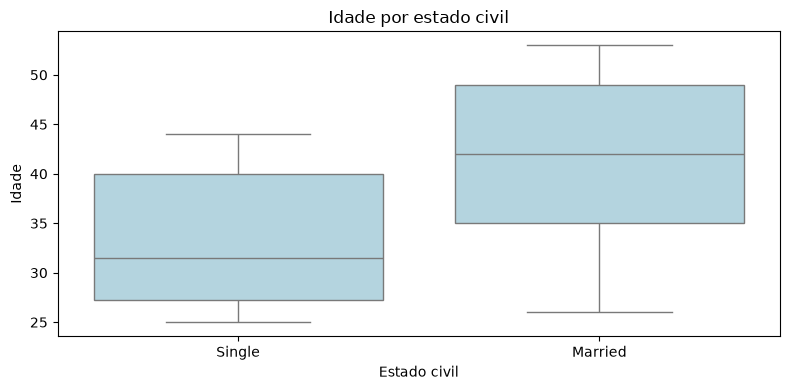

,count,mean,median,std
Marital Status,,,,
Married,68,41.62,42.0,7.98
Single,62,33.00,31.5,6.59


In [264]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Marital Status', y='Age', color='lightblue')
plt.title('Idade por estado civil')
plt.xlabel('Estado civil')
plt.ylabel('Idade')
plt.tight_layout()
plt.show()

df.groupby('Marital Status')['Age'].agg(['count', 'mean', 'median', 'std']).round(2)

**Insight :** ao comparar a idade entre pessoas casadas e solteiras, observa-se que as pessoas casadas apresentam média de idade de 41,62 anos e mediana de 42 anos, enquanto as pessoas solteiras têm média de 33,00 anos e mediana de 31,5 anos. Isso indica que, nesta base, pessoas casadas tendem a ser mais velhas do que as solteiras. Além disso, o desvio padrão das idades é maior entre as pessoas casadas (7,98) do que entre as solteiras (6,59), mostrando uma maior variação de idade dentro do grupo de casados. Portanto, há um indício de relação entre idade e estado civil: quanto mais avançada a idade, maior a proporção de pessoas casadas na amostra.

## 2. Score de crédito x Escolaridade

**Explicação do código:** como as duas variáveis são categóricas, é criada uma tabela cruzada com percentuais por nível de escolaridade. Em seguida, um gráfico de barras empilhadas mostra a proporção de cada score de crédito dentro de cada grupo educacional.

Credit Score         Average    High    Low
Education                                  
Associate's Degree     60.00   20.00  20.00
Bachelor's Degree      41.18   58.82   0.00
Doctorate               4.17   95.83   0.00
High School Diploma    18.18   50.00  31.82
Master's Degree         0.00  100.00   0.00


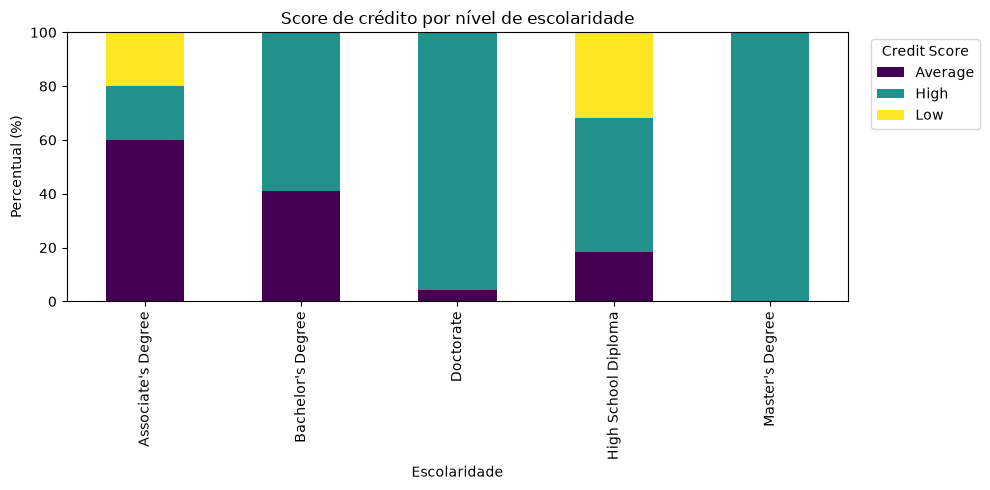

In [265]:
tabela = pd.crosstab(df['Education'], df['Credit Score'], normalize='index') * 100
print(tabela.round(2))

tabela.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5),
    colormap='viridis'
)

plt.title('Score de crédito por nível de escolaridade')
plt.xlabel('Escolaridade')
plt.ylabel('Percentual (%)')
plt.legend(title='Credit Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight :** a análise do score de crédito por nível de escolaridade indica uma relação positiva entre escolaridade e score de crédito. Pessoas com `Master's Degree` apresentam 100% de score alto, enquanto pessoas com `Doctorate` têm 95,83% de score alto. Entre quem possui `Bachelor's Degree`, 58,82% também apresentam score alto. Em contrapartida, entre pessoas com `High School Diploma`, apenas 50% têm score alto e 31,82% apresentam score baixo, a maior proporção dessa categoria na base. Já entre pessoas com `Associate's Degree`, 60% possuem score médio e 20% score baixo. Dessa forma, os dados sugerem que níveis mais altos de escolaridade estão associados a uma maior proporção de clientes com score de crédito alto, embora essa relação não comprove causalidade.

## 3. Salário x Idade

**Explicação do código:** o gráfico de dispersão mostra cada pessoa como um ponto, com idade no eixo X e salário no eixo Y. A linha de regressão ajuda a visualizar se existe tendência de aumento ou redução do salário conforme a idade. O `corr()` calcula o coeficiente de correlação entre as duas variáveis.

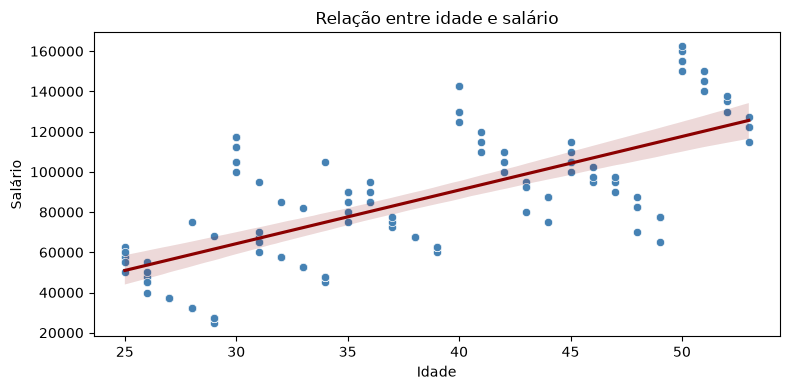

Correlação entre Age e Income: 0.69


In [266]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Age', y='Income', color='steelblue')
sns.regplot(data=df, x='Age', y='Income', scatter=False, color='darkred')
plt.title('Relação entre idade e salário')
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.tight_layout()
plt.show()

correlacao_idade_salario = df['Age'].corr(df['Income'])
print(f'Correlação entre Age e Income: {correlacao_idade_salario:.2f}')

**Insight :** a correlação entre `Age` e `Income` foi de 0,69, indicando uma correlação positiva moderada a forte. Isso sugere que, nesta base, pessoas mais velhas tendem a apresentar salários mais altos. Esse resultado é coerente com a expectativa de que a experiência profissional acumulada ao longo dos anos possa contribuir para um aumento na renda. No entanto, correlação não implica causalidade: a idade não é necessariamente a causa direta do salário, pois outros fatores, como escolaridade, cargo, tempo de experiência e setor de atuação, também podem influenciar esse resultado.

## 4. Salário x Score de crédito

**Explicação do código:** o boxplot compara a distribuição dos salários entre os grupos de score de crédito: `Low`, `Average` e `High`. Isso permite verificar se a mediana salarial tende a aumentar conforme o score melhora.

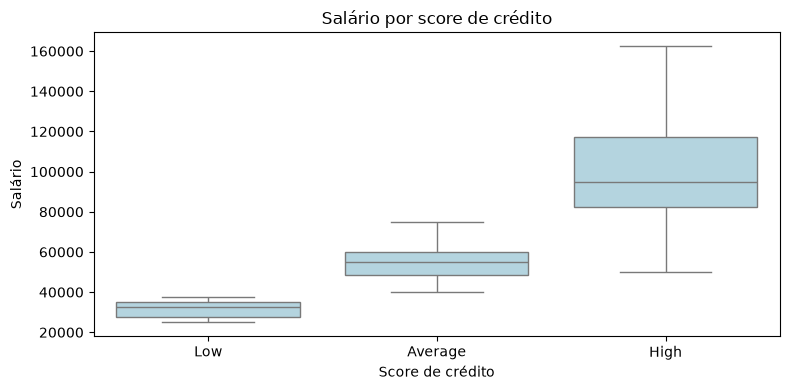

,count,mean,median
Credit Score,,,
Average,31,55822.58,55000.0
High,88,100875.00,95000.0
Low,11,31818.18,32500.0


In [267]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x='Credit Score',
    y='Income',
    order=['Low', 'Average', 'High'],
    color='lightblue'
)
plt.title('Salário por score de crédito')
plt.xlabel('Score de crédito')
plt.ylabel('Salário')
plt.tight_layout()
plt.show()

df.groupby('Credit Score')['Income'].agg(['count', 'mean', 'median']).round(2)

**Insight :** a análise do salário por score de crédito indica uma relação positiva entre renda e score. Clientes com score alto apresentam a maior média salarial, de 100.875,00, e mediana de 95.000,00. Já clientes com score médio possuem média de 55.822,58 e mediana de 55.000,00, enquanto clientes com score baixo apresentam a menor média, de 31.818,18, e mediana de 32.500,00. Dessa forma, observa-se que, à medida que o score de crédito aumenta, o salário também tende a ser maior. Esse resultado sugere que pessoas com rendas mais elevadas tendem a apresentar um perfil de crédito melhor. No entanto, correlação não implica causalidade: o salário pode influenciar o score, mas outros fatores, como histórico de pagamento, dívidas e comportamento financeiro, também devem ser considerados.

## 5. Casa própria x Score de crédito


**Explicação do código:** a tabela cruzada calcula o percentual de cada score de crédito dentro dos grupos “casa própria” e “alugada”. O gráfico de barras empilhadas facilita comparar essas proporções e identificar se clientes com casa própria têm maior concentração de score alto.

Credit Score    Average   High   Low
Home Ownership                      
Owned              2.33  97.67   0.0
Rented            65.91   9.09  25.0


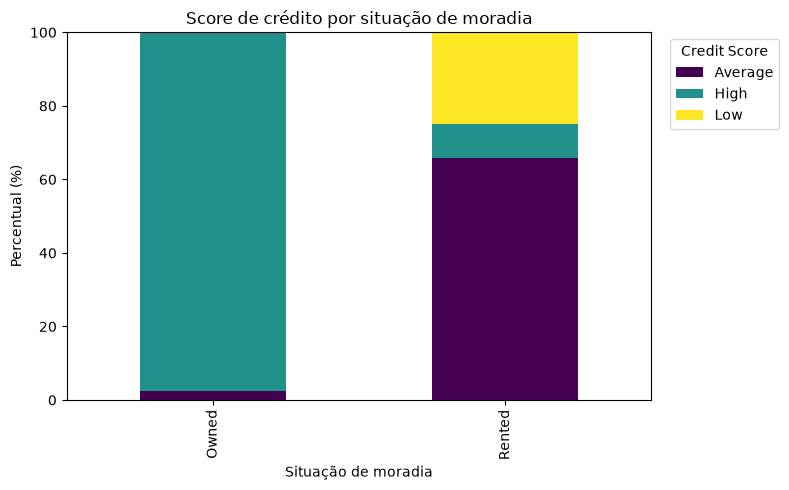

In [268]:
tabela_casa = pd.crosstab(df['Home Ownership'], df['Credit Score'], normalize='index') * 100
print(tabela_casa.round(2))

tabela_casa.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    colormap='viridis'
)

plt.title('Score de crédito por situação de moradia')
plt.xlabel('Situação de moradia')
plt.ylabel('Percentual (%)')
plt.legend(title='Credit Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight :** a análise do score de crédito por situação de moradia indica que clientes com casa própria tendem a apresentar um score de crédito mais alto. Entre as pessoas que possuem imóvel próprio, 97,67% têm score alto, 2,33% score médio e nenhuma apresenta score baixo. Já entre as pessoas que moram em imóveis alugados, apenas 9,09% possuem score alto, enquanto 65,91% têm score médio e 25% apresentam score baixo. Dessa forma, os dados sugerem uma forte associação entre possuir casa própria e um melhor perfil de crédito. No entanto, essa relação não comprova causalidade: possuir imóvel próprio pode refletir maior estabilidade financeira, mas o score de crédito também pode ser influenciado por outros fatores, como renda, histórico de pagamentos e nível de endividamento.

**E) Que outras perguntas te parecem fazer sentido explorarmos a resposta para conhecermos mais nossa base de dados e o comportamento dos clientes?**

 Elabore mais 3 perguntas e responda utilizando gráficos + insights.

Essas três perguntas complementam a análise anterior porque investigam possíveis relações entre o perfil pessoal, financeiro e de crédito dos clientes. A relação entre idade e score pode indicar se clientes mais velhos possuem melhor histórico de crédito. A relação entre escolaridade e salário ajuda a entender se a formação influencia a renda. Por fim, a relação entre estado civil e score pode revelar diferenças no comportamento financeiro entre pessoas casadas e solteiras. Essas análises são úteis para conhecer melhor a base e apoiar decisões futuras de segmentação de clientes.

## 1. Idade x Salário x Score de crédito



**Explicação do código:** o gráfico de dispersão relaciona idade e salário, enquanto as cores representam o score de crédito de cada cliente. Assim, é possível observar se pessoas mais velhas e com salários mais altos tendem a se concentrar no grupo de score alto. A linha de regressão geral mostra a tendência entre idade e salário, sem separar por score.

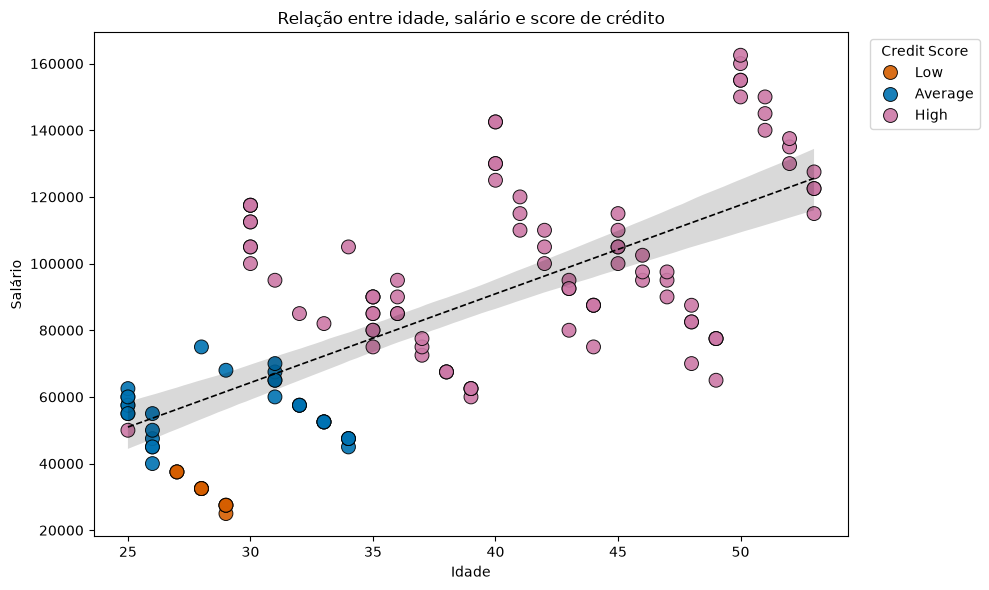

Age               Income                    
             count   mean median  count       mean   median
Credit Score                                               
Average         31  29.26   31.0     31   55822.58  55000.0
High            88  41.59   42.0     88  100875.00  95000.0
Low             11  28.09   28.0     11   31818.18  32500.0

In [269]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Income',
    hue='Credit Score',
    hue_order=['Low', 'Average', 'High'],
    palette={
        'Low': '#D55E00',      # vermelho-alaranjado
        'Average': '#0072B2',  # azul escuro
        'High': '#CC79A7'      # rosa/roxo
    },
    s=100,
    alpha=0.9,
    edgecolor='black',
    linewidth=0.7
)

sns.regplot(
    data=df,
    x='Age',
    y='Income',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--', 'linewidth': 1.2}
)

plt.title('Relação entre idade, salário e score de crédito')
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.legend(
    title='Credit Score',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)
plt.tight_layout()
plt.show()

df.groupby('Credit Score')[['Age', 'Income']].agg(['count', 'mean', 'median']).round(2)

**Insight :** a análise entre idade, salário e score de crédito indica que clientes com score alto apresentam, em média, maior idade e maior renda. O grupo `High` possui média de idade de 41,59 anos e salário médio de 100.875,00, com mediana de 42 anos e 95.000,00. Já os grupos `Average` e `Low` apresentam perfis semelhantes em relação à idade, com médias de 29,26 e 28,09 anos, respectivamente, mas diferem principalmente no salário: o grupo `Average` tem média salarial de 55.822,58, enquanto o grupo `Low` tem média de 31.818,18. Dessa forma, observa-se que clientes mais velhos e com salários mais elevados tendem a apresentar score de crédito alto. Esse resultado sugere que maior experiência profissional e maior renda podem estar associados a um melhor perfil de crédito. No entanto, correlação não implica causalidade, pois o score também pode ser influenciado por histórico de pagamentos, endividamento e comportamento financeiro.

## 2. Escolaridade x Salário

**Explicação do código:** o boxplot compara a distribuição salarial entre os diferentes níveis de escolaridade. Ele permite observar se pessoas com maior escolaridade tendem a receber salários mais altos. A tabela mostra a média e a mediana salarial de cada grupo.

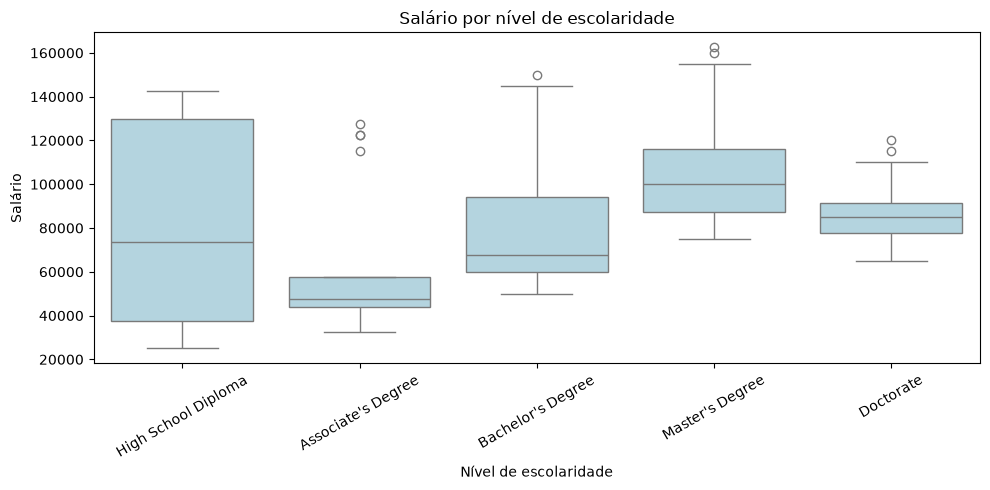

,count,mean,median
Education,,,
Associate's Degree,20,60250.00,47500.0
Bachelor's Degree,34,78382.35,67500.0
Doctorate,24,86895.83,85000.0
High School Diploma,22,81704.55,73750.0
Master's Degree,30,106816.67,100000.0


In [270]:
ordem_educacao = [
    'High School Diploma',
    "Associate's Degree",
    "Bachelor's Degree",
    "Master's Degree",
    'Doctorate'
]

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='Education',
    y='Income',
    order=ordem_educacao,
    color='lightblue'
)
plt.title('Salário por nível de escolaridade')
plt.xlabel('Nível de escolaridade')
plt.ylabel('Salário')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

df.groupby('Education')['Income'].agg(['count', 'mean', 'median']).round(2)

**Insight :** a análise entre escolaridade e salário indica que, de modo geral, níveis mais altos de escolaridade estão associados a salários mais elevados. Pessoas com `Master's Degree` apresentam a maior média salarial, de 106.816,67, e mediana de 100.000,00. Em seguida aparecem pessoas com `Doctorate`, com média de 86.895,83 e mediana de 85.000,00, e pessoas com `High School Diploma`, com média de 81.704,55 e mediana de 73.750,00. Já o grupo com `Associate's Degree` apresenta a menor média salarial, de 60.250,00, e mediana de 47.500,00. Pessoas com `Bachelor's Degree` possuem média de 78.382,35 e mediana de 67.500,00. Embora o grupo com `High School Diploma` apresente uma média relativamente alta, a mediana menor que a dos grupos com graduação indica que poucos salários elevados podem estar influenciando essa média. De forma geral, os dados sugerem que maior escolaridade tende a estar relacionada a rendas mais altas, especialmente entre pessoas com mestrado. No entanto, correlação não implica causalidade, pois o salário também pode ser influenciado por experiência, área de atuação, cargo e tempo de trabalho.

## 3. Estado civil x Score de crédito

**Explicação do código:** como as duas variáveis são categóricas, é criada uma tabela cruzada com percentuais de score de crédito dentro de cada estado civil. O gráfico de barras empilhadas facilita comparar a proporção de clientes com score baixo, médio e alto entre pessoas casadas e solteiras.

Credit Score    Average   High    Low
Marital Status                       
Married            2.94  97.06   0.00
Single            46.77  35.48  17.74


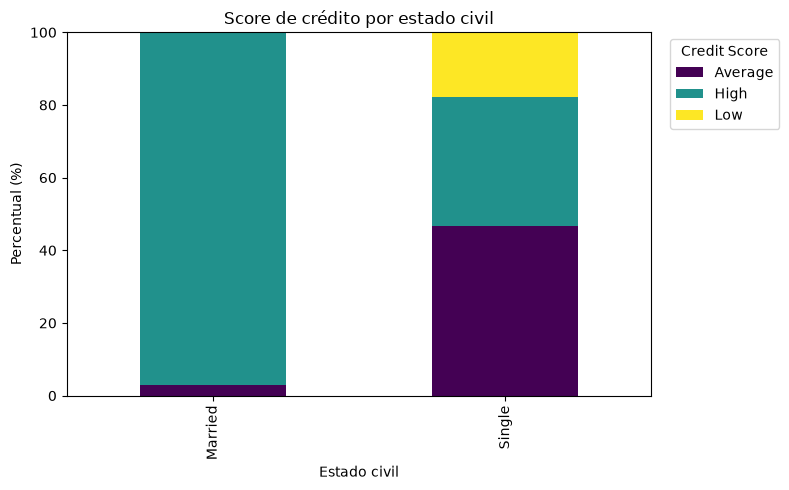

In [271]:
tabela_estado_civil = pd.crosstab(
    df['Marital Status'],
    df['Credit Score'],
    normalize='index'
) * 100

print(tabela_estado_civil.round(2))

tabela_estado_civil.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    colormap='viridis'
)

plt.title('Score de crédito por estado civil')
plt.xlabel('Estado civil')
plt.ylabel('Percentual (%)')
plt.legend(title='Credit Score', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight :** a análise entre estado civil e score de crédito indica que pessoas casadas tendem a apresentar um perfil de crédito melhor. Entre os clientes casados, 97,06% possuem score alto, 2,94% score médio e nenhum apresenta score baixo. Já entre as pessoas solteiras, apenas 35,48% têm score alto, enquanto 46,77% apresentam score médio e 17,74% score baixo. Dessa forma, observa-se uma forte associação entre ser casado e possuir score de crédito alto nesta base. Esse resultado pode estar relacionado a maior estabilidade financeira, renda familiar ou comportamento de crédito, mas não comprova causalidade: o estado civil, por si só, não determina o score. Outros fatores, como renda, idade, histórico de pagamentos e nível de endividamento, também devem ser considerados.

# Etapa 3: Relize os passos que vimos no módulo 17, de Correlação, Balanceamento, atributos categóricos e divisão base treino e teste.

**A) Vamos começar pela análise de correlação, plote da forma que achar melhor a análise de correlação, seja pela tabela ou pelo gráfico da matriz.**

                     Age  Income  Number of Children
Age                 1.00    0.69                0.08
Income              0.69    1.00                0.11
Number of Children  0.08    0.11                1.00


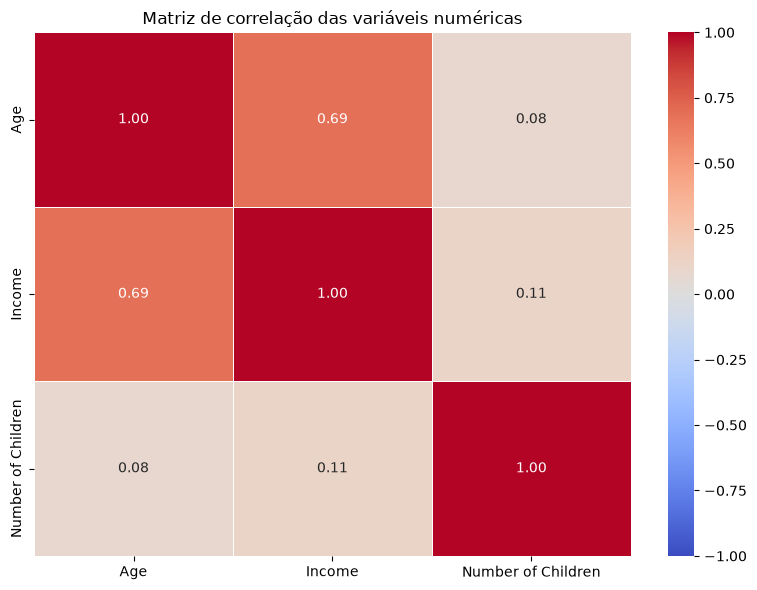

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tabela de correlação
correlacao = df.corr(numeric_only=True)
print(correlacao.round(2))

# Gráfico heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5
)
plt.title('Matriz de correlação das variáveis numéricas')
plt.tight_layout()
plt.show()

**B) Você encontrou variáveis que tem uma média ou alta correlação? Se sim, quais? Te parece fazer sentido essas variáveis terem alta correlação? Justifique.**

Sim. Encontrei correlação moderada a forte entre `Age` e `Income`, com valor de 0,69. Isso indica que pessoas mais velhas tendem a ter salários mais altos.

Essa relação faz sentido, pois pessoas mais velhas geralmente têm mais experiência profissional, o que pode contribuir para salários maiores. No entanto, correlação não significa causalidade, pois outros fatores também influenciam o salário.

As variáveis `Age` e `Number of Children` tiveram correlação de 0,08, e `Income` e `Number of Children` tiveram correlação de 0,11. Isso mostra que essas relações são fracas.

In [273]:
print(df.columns)

Index(['Age', 'Gender', 'Income', 'Education', 'Marital Status',
       'Number of Children', 'Home Ownership', 'Credit Score'],
      dtype='str')


**C) Temos muitos atributos categóricos nessa base, não? Vamos realizar a o tratamento desses atributos utilizando Label Encoder ou one hot. Após, exclua as colunas categóricas.**

In [274]:
# Variáveis com apenas duas categorias
colunas_label = ['Gender', 'Marital Status', 'Home Ownership']

label_encoder = LabelEncoder()

for coluna in colunas_label:
    df[coluna] = label_encoder.fit_transform(df[coluna])

# Variáveis com três ou mais categorias

df = pd.get_dummies(
    df,
    columns=['Education'],
    drop_first=True,
    dtype=int
)

df.head()

,Age,Gender,Income,Marital Status,Number of Children,Home Ownership,Credit Score,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25.0,0,50000.0,1,0,1,High,1,0,0,0
1,30.0,1,100000.0,0,2,0,High,0,0,0,1
2,35.0,0,75000.0,0,1,0,High,0,1,0,0
3,40.0,1,125000.0,1,0,0,High,0,0,1,0
4,45.0,0,100000.0,0,3,0,High,1,0,0,0


In [275]:
# Conferir as categorias originais
print(df['Credit Score'].unique())

<StringArray>
['High', 'Average', 'Low']
Length: 3, dtype: str


In [276]:
df['Credit Score'] = df['Credit Score'].map({
    'Low': 0,
    'Average': 1,
    'High': 2
}).astype(int)

In [277]:
print(df['Credit Score'].dtype)
print(df['Credit Score'].value_counts())

int64
Credit Score
2    88
1    31
0    11
Name: count, dtype: int64


In [278]:
df.info()
df.columns

<class 'pandas.DataFrame'>
Index: 130 entries, 0 to 163
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            130 non-null    float64
 1   Gender                         130 non-null    int64  
 2   Income                         130 non-null    float64
 3   Marital Status                 130 non-null    int64  
 4   Number of Children             130 non-null    int64  
 5   Home Ownership                 130 non-null    int64  
 6   Credit Score                   130 non-null    int64  
 7   Education_Bachelor's Degree    130 non-null    int64  
 8   Education_Doctorate            130 non-null    int64  
 9   Education_High School Diploma  130 non-null    int64  
 10  Education_Master's Degree      130 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 12.2 KB


Index(['Age', 'Gender', 'Income', 'Marital Status', 'Number of Children',
       'Home Ownership', 'Credit Score', 'Education_Bachelor's Degree',
       'Education_Doctorate', 'Education_High School Diploma',
       'Education_Master's Degree'],
      dtype='str')

In [279]:
df['Home Ownership'] = df['Home Ownership'].replace({
    0: 1,   # Owned vira 1
    1: 0    # Rented vira 0
})
df['Marital Status'] = df['Marital Status'].replace({
    0: 1,   # Married vira 1
    1: 0    # Single vira 0
})

**D) Vamos plotar novamente a correlação, agora observando com as variáveis categóricas. Identifique se temos novas variáveis com forte correlação.**

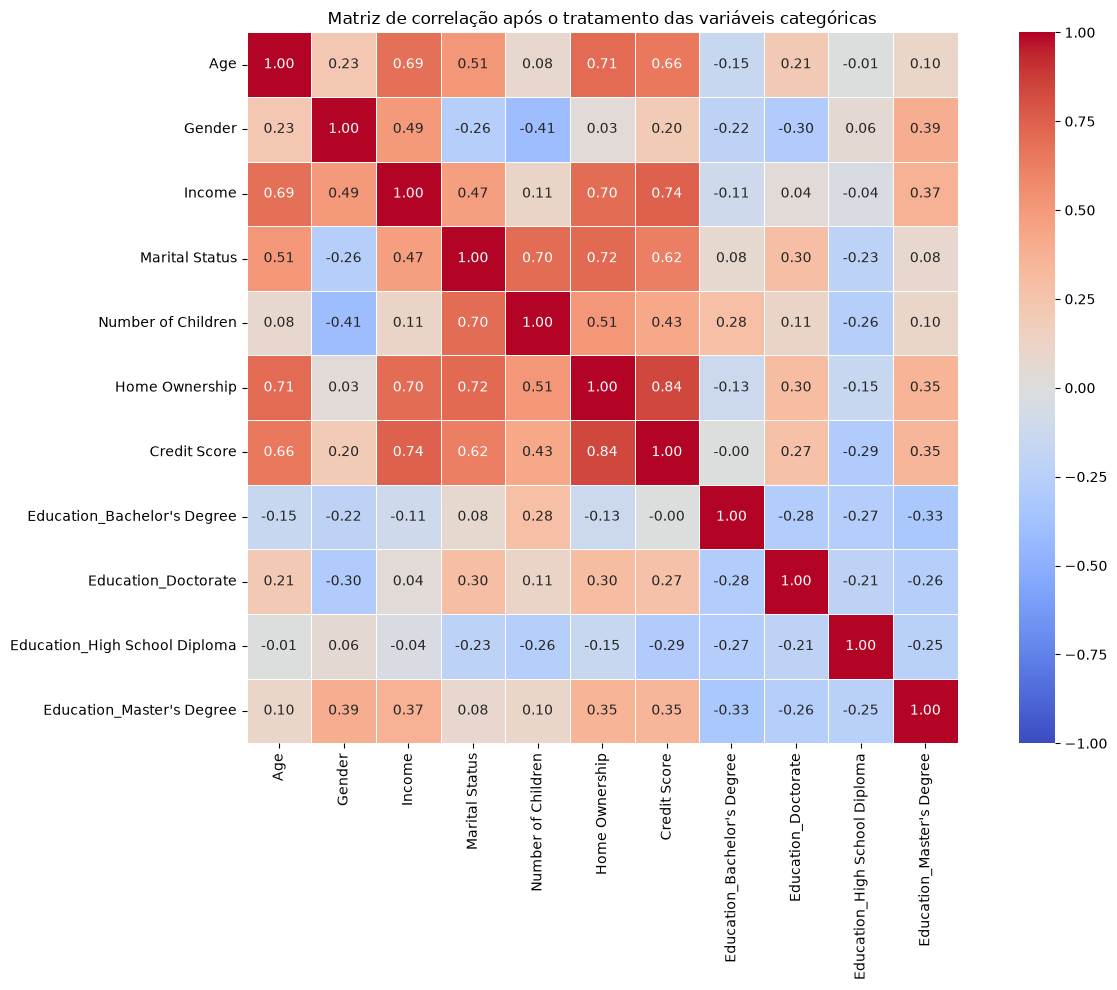

,Age,Gender,Income,Marital Status,Number of Children,Home Ownership,Credit Score,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
Age,1.00,0.23,0.69,0.51,0.08,0.71,0.66,-0.15,0.21,-0.01,0.10
Gender,0.23,1.00,0.49,-0.26,-0.41,0.03,0.20,-0.22,-0.30,0.06,0.39
Income,0.69,0.49,1.00,0.47,0.11,0.70,0.74,-0.11,0.04,-0.04,0.37
Marital Status,0.51,-0.26,0.47,1.00,0.70,0.72,0.62,0.08,0.30,-0.23,0.08
Number of Children,0.08,-0.41,0.11,0.70,1.00,0.51,0.43,0.28,0.11,-0.26,0.10
Home Ownership,0.71,0.03,0.70,0.72,0.51,1.00,0.84,-0.13,0.30,-0.15,0.35
Credit Score,0.66,0.20,0.74,0.62,0.43,0.84,1.00,-0.00,0.27,-0.29,0.35
Education_Bachelor's Degree,-0.15,-0.22,-0.11,0.08,0.28,-0.13,-0.00,1.00,-0.28,-0.27,-0.33
Education_Doctorate,0.21,-0.30,0.04,0.30,0.11,0.30,0.27,-0.28,1.00,-0.21,-0.26
Education_High School Diploma,-0.01,0.06,-0.04,-0.23,-0.26,-0.15,-0.29,-0.27,-0.21,1.00,-0.25


In [280]:
plt.figure(figsize=(14, 10))

correlacao = df.corr(numeric_only=True)

sns.heatmap(
    correlacao,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

plt.title('Matriz de correlação após o tratamento das variáveis categóricas')
plt.tight_layout()
plt.show()

correlacao.round(2)

**Insight:** após incluir as variáveis categóricas codificadas, foram identificadas novas correlações fortes. A mais expressiva é entre `Home Ownership` e `Credit Score`, com correlação de 0,84. Como a variável `Home Ownership` foi codificada com o valor 1 representando clientes com casa própria (`Owned`) e o valor 0 representando clientes que moram em imóveis alugados (`Rented`), e a variável `Credit Score` foi codificada com `Low = 0`, `Average = 1` e `High = 2`, essa correlação positiva indica que clientes com casa própria tendem a apresentar scores de crédito mais elevados.

Também foram identificadas correlações fortes entre `Income` e `Credit Score` (0,74), entre `Age` e `Credit Score` (0,66) e entre `Marital Status` e `Credit Score` (0,62). Isso indica que clientes com salários mais altos, maior idade e estado civil casado tendem a apresentar scores de crédito mais elevados nesta base.

Além disso, `Marital Status` apresentou correlação positiva forte com `Number of Children` (0,70), sugerindo que pessoas casadas tendem a ter mais filhos nesta base. `Marital Status` também apresentou correlação positiva de 0,72 com `Home Ownership`, indicando que pessoas casadas tendem a estar mais associadas à casa própria. Por fim, `Age` e `Income` mantiveram correlação positiva forte de 0,69, reforçando que pessoas mais velhas tendem a apresentar salários mais elevados.

É importante destacar que correlação não implica causalidade. As relações identificadas mostram associação entre as variáveis, mas não comprovam que uma variável causa a outra.

**F) Faça a separação da base em treino e teste e verifique utilizando shape:**

In [281]:
# Variável alvo
y = df['Credit Score']

# Variáveis explicativas
X = df.drop(columns=['Credit Score'])

# Separação da base em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verificando as dimensões
print('Shape de X_treino:', X_treino.shape)
print('Shape de X_teste:', X_teste.shape)
print('Shape de y_treino:', y_treino.shape)
print('Shape de y_teste:', y_teste.shape)

Shape de X_treino: (104, 10)
Shape de X_teste: (26, 10)
Shape de y_treino: (104,)
Shape de y_teste: (26,)


**G) É hora de verificar se nossa coluna de Score de crédito está balanceada, verifique através de um gráfico e traga sua opinião acerca do balanceamento.**

Credit Score
0    11
1    31
2    88
Name: count, dtype: int64
Credit Score
0     8.46
1    23.85
2    67.69
Name: proportion, dtype: float64


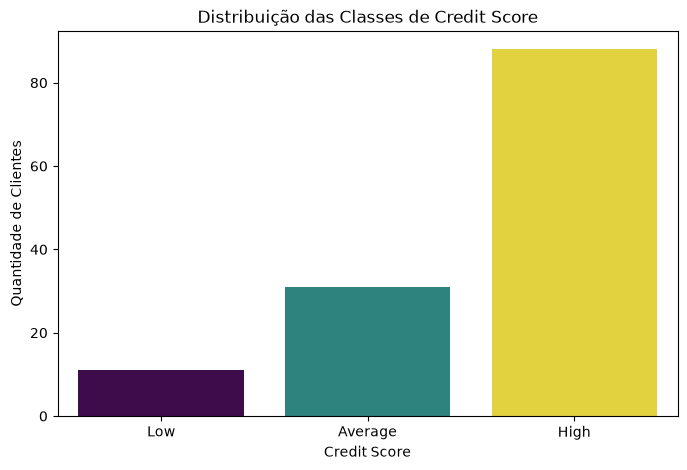

In [282]:
# Contagem absoluta das classes
contagem_score = df['Credit Score'].value_counts().sort_index()
print(contagem_score)

# Contagem percentual das classes
proporcao_score = df['Credit Score'].value_counts(normalize=True).sort_index() * 100
print(proporcao_score.round(2))

# Gráfico de barras
plt.figure(figsize=(8, 5))

sns.countplot(
    x='Credit Score',
    hue='Credit Score',
    data=df,
    order=[0, 1, 2],
    palette='viridis',
    legend=False
)

plt.title('Distribuição das Classes de Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Quantidade de Clientes')
plt.xticks(
    ticks=[0, 1, 2],
    labels=['Low', 'Average', 'High']
)

plt.show()

A variável alvo `Credit Score` está desbalanceada. A classe `High` é a mais frequente, com 88 clientes (67,69%), seguida pela classe `Average`, com 31 clientes (23,85%). A classe `Low` é a menor, com apenas 11 clientes (8,46%).

Por isso, o modelo pode ter mais facilidade em prever a classe `High` e mais dificuldade em prever corretamente a classe `Low`. Diante desse desbalanceamento, será realizado o balanceamento apenas na base de treino, para evitar que informações da base de teste sejam utilizadas no processo de treinamento e comprometam a avaliação do modelo.

**H) Vamos realizar o balancecamento dos dados da coluna de credit score.**
Se lembre que realizazmos apenas para a base de treino.

In [283]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_treino_balanceado, y_treino_balanceado = smote.fit_resample(
    X_treino,
    y_treino
)

# Verificar o balanceamento
print('Antes do balanceamento:')
print(y_treino.value_counts())

print('\nDepois do balanceamento:')
print(y_treino_balanceado.value_counts())

print('\nShape de X_treino_balanceado:', X_treino_balanceado.shape)
print('Shape de y_treino_balanceado:', y_treino_balanceado.shape)

Antes do balanceamento:
Credit Score
2    70
1    25
0     9
Name: count, dtype: int64

Depois do balanceamento:
Credit Score
1    70
2    70
0    70
Name: count, dtype: int64

Shape de X_treino_balanceado: (210, 10)
Shape de y_treino_balanceado: (210,)


In [284]:
# Verificando os tamanhos antes e depois do SMOTE
print('Shape de X_treino:', X_treino.shape)
print('Shape de y_treino:', y_treino.shape)

print('\nShape de X_treino_balanceado:', X_treino_balanceado.shape)
print('Shape de y_treino_balanceado:', y_treino_balanceado.shape)

print('\nShape de X_teste:', X_teste.shape)
print('Shape de y_teste:', y_teste.shape)

Shape de X_treino: (104, 10)
Shape de y_treino: (104,)

Shape de X_treino_balanceado: (210, 10)
Shape de y_treino_balanceado: (210,)

Shape de X_teste: (26, 10)
Shape de y_teste: (26,)


In [285]:
print('Classes da base de treino antes do SMOTE:')
print(y_treino.value_counts())

print('\nClasses da base de treino depois do SMOTE:')
print(y_treino_balanceado.value_counts())

print('\nClasses da base de teste:')
print(y_teste.value_counts())

Classes da base de treino antes do SMOTE:
Credit Score
2    70
1    25
0     9
Name: count, dtype: int64

Classes da base de treino depois do SMOTE:
Credit Score
1    70
2    70
0    70
Name: count, dtype: int64

Classes da base de teste:
Credit Score
2    18
1     6
0     2
Name: count, dtype: int64
